In [1]:
"""
Re‑creates your current world + camera demo and opens a matplotlib window.
Run:  python -m examples.demo_world
"""
import numpy as np
import torch

from nerflab import (
    Intrinsics, Camera, Box, Sphere, World, plot_world, CFG, pose_H, make_pose_cases, save_world, load_world, World, Box, Sphere
)
from nerflab.camera.presets import make_spherical_poses


In [2]:
world = load_world("../data/world.json")

## GPU + dtype control (e.g., float32 on CUDA):

In [3]:
# build preset dictionary
device = torch.device("cuda") if torch.cuda.is_available() else None
HB = make_spherical_poses(c=1200, radius=3.0, device='cuda', dtype=torch.float16)


print(HB.shape)
print(HB.dtype)
print(HB.dtype)

torch.Size([1200, 4, 4])
torch.float16
torch.float16


In [4]:
print(HB.device)

cuda:0


In [5]:
# --- camera ------------------------------------------------------------------
cam_batched   = Camera(HB, repair_validate_se3=True)
# --- sample rays -------------------------------------------------------------
O_B, D_B = cam_batched.get_rays_sampled(frame="world", rays_per_pose=4096)
print(O_B.device)
print(O_B.dtype)
print("deltaB shape:", O_B.shape)
print("tB shape:", D_B.shape)

cuda:0
torch.float32
deltaB shape: torch.Size([1200, 4096, 3])
tB shape: torch.Size([1200, 4096, 3])


In [6]:
tB, deltaB, ptsB = cam_batched.sample_along_rays(O_B, D_B)
print("points shape:", ptsB.shape)
print("deltaB shape:", deltaB.shape)
print("tB shape:", tB.shape)

points shape: torch.Size([1200, 4096, 20, 3])
deltaB shape: torch.Size([1200, 4096, 20])
tB shape: torch.Size([1200, 4096, 20])


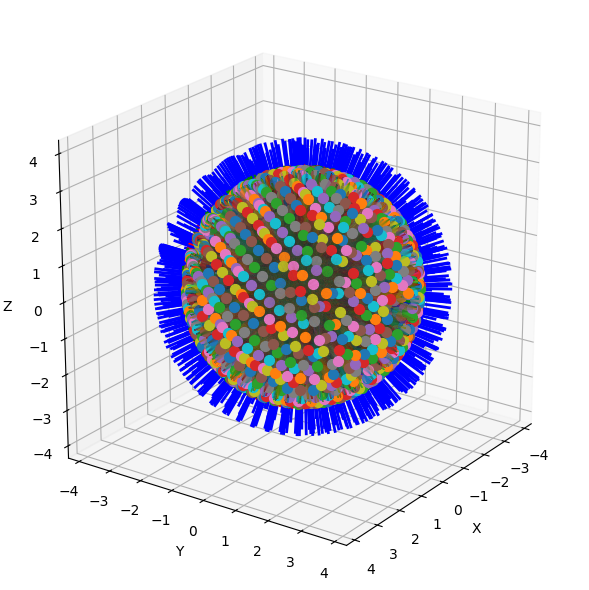

In [7]:
# 1) Single batched camera, draw 1k rays/pose and samples
plot_world(
    world,
    cameras=cam_batched.to('cpu'),
    cam_indices="all",
    draw_rays=True, ray_mode="lines", rays_per_pose=100,
    draw_samples=True, samples_deterministic=True, ray_alpha=0.01, samples_alpha=0.002, shape_edge_alpha=1, shape_face_alpha= 1, set_labels=False
)

